In [ ]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict
import seaborn as sns

class ModelExplainer:
    def __init__(self, model_path: str, data_path: str):
        """
        Initialize the ModelExplainer with model and data paths.

        Args:
            model_path: Path to the saved model file
            data_path: Path to the processed data CSV
        """
        # Load model and data
        self.pipeline = joblib.load(model_path)
        self.data = pd.read_csv(data_path)

        # Get the XGBoost model from the pipeline
        self.model = self.pipeline.named_steps['model']

        # Prepare features
        self.X = self.data.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
        self.y = self.data['infraction']

        # Transform features using the pipeline's preprocessing steps
        self.X_transformed = self.pipeline.named_steps['sampler'].fit_resample(self.X, self.y)[0]

        self.explainer = None
        self.shap_values = None

    def setup_explainer(self, sample_size: int = 1000) -> None:
        """
        Set up the SHAP explainer with a sample of data.

        Args:
            sample_size: Number of samples to use for explanation
        """
        try:
            # Sample data for faster computation
            indices = np.random.choice(len(self.X), min(sample_size, len(self.X)), replace=False)
            X_sample = self.X.iloc[indices]

            # Create TreeExplainer
            self.explainer = shap.TreeExplainer(self.model)

            # Calculate SHAP values
            self.shap_values = self.explainer.shap_values(X_sample)

            if isinstance(self.shap_values, list):
                # For binary classification, we typically want the positive class
                self.shap_values = self.shap_values[1]

            print(f"SHAP values calculated for {sample_size} samples")
            print(f"Shape of SHAP values: {self.shap_values.shape}")

        except Exception as e:
            print(f"Error in setup_explainer: {str(e)}")
            raise

    def plot_global_importance(self, max_display: int = 20) -> None:
        """
        Plot global feature importance using SHAP values.

        Args:
            max_display: Maximum number of features to display
        """
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                self.shap_values,
                self.X.iloc[self.shap_values.shape[0]],
                plot_type="bar",
                max_display=max_display,
                show=False
            )
            plt.title("Global Feature Importance")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error in plot_global_importance: {str(e)}")
            raise

    def plot_feature_impact(self, max_display: int = 20) -> None:
        """
        Plot detailed feature impact showing both magnitude and direction.

        Args:
            max_display: Maximum number of features to display
        """
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                self.shap_values,
                self.X.iloc[self.shap_values.shape[0]],
                max_display=max_display,
                show=False
            )
            plt.title("Feature Impact Analysis")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error in plot_feature_impact: {str(e)}")
            raise

    def get_top_features(self, n: int = 10) -> Dict[str, float]:
        """
        Get the top n most important features and their mean absolute SHAP values.

        Args:
            n: Number of top features to return

        Returns:
            Dictionary of feature names and their importance scores
        """
        try:
            feature_importance = np.abs(self.shap_values).mean(0)
            feature_importance_dict = dict(zip(self.X.columns, feature_importance))
            return dict(sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:n])
        except Exception as e:
            print(f"Error in get_top_features: {str(e)}")
            raise

    def explain_single_prediction(self, transaction_idx: int) -> None:
        """
        Explain a single prediction using SHAP force plot and feature contributions.

        Args:
            transaction_idx: Index of the transaction to explain
        """
        try:
            # Get the specific transaction
            transaction = self.X.iloc[transaction_idx:transaction_idx+1]

            # Calculate SHAP values for this transaction
            shap_values = self.explainer.shap_values(transaction)

            if isinstance(shap_values, list):
                shap_values = shap_values[1]

            # Create waterfall plot (more informative than force plot)
            plt.figure(figsize=(12, 6))
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values[0],
                    base_values=self.explainer.expected_value if not isinstance(self.explainer.expected_value, list)
                    else self.explainer.expected_value[1],
                    data=transaction.iloc[0],
                    feature_names=transaction.columns
                ),
                show=False
            )
            plt.title(f"Feature Contributions for Transaction {transaction_idx}")
            plt.tight_layout()
            plt.show()

            # Show feature contributions as a table
            contributions = pd.DataFrame({
                'Feature': self.X.columns,
                'Value': transaction.values[0],
                'SHAP value': shap_values[0]
            }).sort_values('SHAP value', key=abs, ascending=False)

            print("\nTop Feature Contributions:")
            print(contributions.head(10))

        except Exception as e:
            print(f"Error in explain_single_prediction: {str(e)}")
            raise

    def plot_feature_dependence(self, feature_name: str) -> None:
        """
        Plot the dependence of SHAP values on a specific feature.

        Args:
            feature_name: Name of the feature to analyze
        """
        try:
            if feature_name not in self.X.columns:
                raise ValueError(f"Feature '{feature_name}' not found in dataset")

            plt.figure(figsize=(10, 6))
            shap.dependence_plot(
                feature_name,
                self.shap_values,
                self.X.iloc[self.shap_values.shape[0]],
                show=False
            )
            plt.title(f"SHAP Dependence Plot for {feature_name}")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error in plot_feature_dependence: {str(e)}")
            raise

def main():
    # Initialize explainer
    explainer = ModelExplainer(
        model_path='models/xgboost_model_20250212_144931.pkl',
        data_path='data/processed/df_treated.csv'
    )

    # Setup explainer with sample data
    print("\nSetting up explainer...")
    explainer.setup_explainer(sample_size=1000)

    # Global feature importance
    print("\nPlotting global feature importance...")
    explainer.plot_global_importance()

    # Feature impact analysis
    print("\nPlotting feature impact analysis...")
    explainer.plot_feature_impact()

    # Get top features
    print("\nTop 10 most important features:")
    top_features = explainer.get_top_features(10)
    for feature, importance in top_features.items():
        print(f"{feature}: {importance:.4f}")

    # Explain a specific transaction (e.g., first fraudulent transaction)
    fraudulent_idx = explainer.y[explainer.y == 1].index[0]
    print(f"\nExplaining fraudulent transaction (index {fraudulent_idx})...")
    explainer.explain_single_prediction(fraudulent_idx)

    # Plot dependence plots for top 3 features
    print("\nPlotting feature dependence for top features...")
    for feature in list(top_features.keys())[:3]:
        explainer.plot_feature_dependence(feature)

if __name__ == "__main__":
    main()

In [ ]:
# Initialize and setup
explainer = ModelExplainer(
    model_path='../model/supervised/xgboost_model_20250212_144931.pkl',
    data_path='../data/processed/df_treated.csv'
)
explainer.setup_explainer(sample_size=100000)

# Generate visualizations
explainer.plot_global_importance()  # Bar plot of feature importance
explainer.plot_feature_impact()     # Detailed feature impact
explainer.explain_single_prediction(transaction_idx=0)  # Single prediction explanation
explainer.plot_feature_dependence('amount')  # Feature dependence plot

In [ ]:
# Set the style for all plots
sns.set_style("whitegrid")

class ModelExplainer:
    def __init__(self, model_path: str, data_path: str):
        """
        Initialize the ModelExplainer with model and data paths.
        """
        # Load model and data
        self.pipeline = joblib.load(model_path)
        self.data = pd.read_csv(data_path)

        # Get the XGBoost model from the pipeline
        self.model = self.pipeline.named_steps['model']

        # Prepare features
        self.X = self.data.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
        self.y = self.data['infraction']

        self.explainer = None
        self.shap_values = None
        self.X_sample = None

    def setup_explainer(self, sample_size: int = 10000) -> None:
        """
        Set up the SHAP explainer with a sample of data.
        """
        try:
            # Sample data for faster computation
            indices = np.random.choice(len(self.X), min(sample_size, len(self.X)), replace=False)
            self.X_sample = self.X.iloc[indices].copy()

            # Create TreeExplainer
            self.explainer = shap.TreeExplainer(self.model)

            # Calculate SHAP values
            self.shap_values = self.explainer.shap_values(self.X_sample)

            if isinstance(self.shap_values, list):
                self.shap_values = self.shap_values[1]

            print(f"SHAP values calculated for {sample_size} samples")

        except Exception as e:
            print(f"Error in setup_explainer: {str(e)}")
            raise

    def plot_feature_importance(self, max_display: int = 20) -> None:
        """
        Plot feature importance using seaborn.
        """
        if self.shap_values is None:
            raise ValueError("Please run setup_explainer first")

        # Calculate mean absolute SHAP values for each feature
        feature_importance = pd.DataFrame({
            'Feature': self.X.columns,
            'Importance': np.abs(self.shap_values).mean(0)
        })

        # Sort by importance and take top features
        feature_importance = feature_importance.sort_values('Importance', ascending=False).tail(max_display)

        # Create the plot
        plt.figure(figsize=(12, 8))
        sns.barplot(
            data=feature_importance,
            y='Feature',
            x='Importance',
            palette='viridis'
        )
        plt.title('Feature Importance (Mean |SHAP value|)', pad=20)
        plt.xlabel('Mean |SHAP value|')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

    def plot_feature_impact_distribution(self, max_display: int = 20) -> None:
        """
        Plot feature impact distribution using seaborn.
        """
        if self.shap_values is None:
            raise ValueError("Please run setup_explainer first")

        # Create a DataFrame with feature impacts
        impact_data = []
        for i, feature in enumerate(self.X.columns):
            impact_data.extend([
                {'Feature': feature, 'SHAP Value': value}
                for value in self.shap_values[:, i]
            ])

        impact_df = pd.DataFrame(impact_data)

        # Get top features by mean absolute SHAP value
        top_features = impact_df.groupby('Feature')['SHAP Value'].apply(lambda x: abs(x).mean())\
                              .sort_values(ascending=False)\
                              .head(max_display).index

        # Filter for top features
        impact_df = impact_df[impact_df['Feature'].isin(top_features)]

        # Create the plot
        plt.figure(figsize=(12, 8))
        sns.boxplot(
            data=impact_df,
            y='Feature',
            x='SHAP Value',
            palette='viridis',
            order=top_features
        )
        plt.title('Feature Impact Distribution', pad=20)
        plt.xlabel('SHAP Value')
        plt.ylabel('Feature')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    def plot_feature_correlations(self, max_display: int = 10) -> None:
        """
        Plot feature correlations with SHAP values.
        """
        if self.shap_values is None:
            raise ValueError("Please run setup_explainer first")

        # Calculate correlations between features and their SHAP values
        correlations = []
        for i, feature in enumerate(self.X.columns):
            correlation = np.corrcoef(self.X_sample[feature], self.shap_values[:, i])[0, 1]
            correlations.append({
                'Feature': feature,
                'Correlation': correlation
            })

        corr_df = pd.DataFrame(correlations)
        corr_df['Abs_Correlation'] = abs(corr_df['Correlation'])
        corr_df = corr_df.sort_values('Abs_Correlation', ascending=False).tail(max_display)

        # Create the plot
        plt.figure(figsize=(12, 8))
        sns.barplot(
            data=corr_df,
            y='Feature',
            x='Correlation',
            palette='RdBu_r'
        )
        plt.title('Feature-SHAP Value Correlations', pad=20)
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Feature')
        plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    def explain_single_prediction(self, transaction_idx: int) -> None:
        """
        Explain a single prediction using a custom visualization.
        """
        if self.explainer is None:
            raise ValueError("Please run setup_explainer first")

        # Get the specific transaction
        transaction = self.X.iloc[transaction_idx:transaction_idx+1]

        # Calculate SHAP values for this transaction
        shap_values = self.explainer.shap_values(transaction)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        # Create DataFrame with contributions
        contributions = pd.DataFrame({
            'Feature': self.X.columns,
            'SHAP value': shap_values[0],
            'Value': transaction.values[0]
        }).sort_values('SHAP value', key=abs, ascending=True)

        # Plot top 10 contributions
        plt.figure(figsize=(12, 6))
        colors = ['red' if x < 0 else 'blue' for x in contributions.tail(10)['SHAP value']]
        sns.barplot(
            data=contributions.tail(10),
            y='Feature',
            x='SHAP value',
            palette=colors
        )
        plt.title(f'Top Feature Contributions for Transaction {transaction_idx}', pad=20)
        plt.xlabel('SHAP value (Impact on prediction)')
        plt.ylabel('Feature')
        plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # Print feature values and contributions
        print("\nTop Feature Contributions:")
        contributions_table = contributions.tail(10).sort_values('SHAP value', key=abs, ascending=False)
        print(contributions_table.to_string(float_format=lambda x: '{:.4f}'.format(x)))

    def plot_feature_dependence(self, feature_name: str) -> None:
        """
        Plot the dependence of SHAP values on a specific feature using seaborn.
        """
        if self.shap_values is None or feature_name not in self.X.columns:
            raise ValueError("Invalid feature name or explainer not set up")

        # Create DataFrame for the plot
        feature_idx = list(self.X.columns).index(feature_name)
        plot_data = pd.DataFrame({
            'Feature Value': self.X_sample[feature_name],
            'SHAP Value': self.shap_values[:, feature_idx]
        })

        # Create the plot
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=plot_data,
            x='Feature Value',
            y='SHAP Value',
            alpha=0.6
        )
        sns.regplot(
            data=plot_data,
            x='Feature Value',
            y='SHAP Value',
            scatter=False,
            color='red'
        )
        plt.title(f'SHAP Dependence Plot for {feature_name}', pad=20)
        plt.xlabel(f'{feature_name} Value')
        plt.ylabel('SHAP Value')
        plt.tight_layout()
        plt.show()

def main():
    try:
        # Initialize explainer
        explainer = ModelExplainer(
            model_path='../model/supervised/xgboost_model_20250212_144931.pkl',
            data_path='../data/processed/df_treated.csv'
        )

        # Setup explainer
        print("\nSetting up explainer...")
        explainer.setup_explainer(sample_size=1000000)

        # Generate all plots
        print("\nPlotting feature importance...")
        explainer.plot_feature_importance()

        print("\nPlotting feature impact distribution...")
        explainer.plot_feature_impact_distribution()

        print("\nPlotting feature correlations...")
        explainer.plot_feature_correlations()

        # Explain a specific transaction (first fraudulent transaction)
        fraudulent_idx = explainer.y[explainer.y == 1].index[0]
        print(f"\nExplaining fraudulent transaction (index {fraudulent_idx})...")
        explainer.explain_single_prediction(fraudulent_idx)

        # Plot dependence for top feature
        top_feature = explainer.get_feature_importance().index[0]
        print(f"\nPlotting feature dependence for {top_feature}...")
        explainer.plot_feature_dependence(top_feature)

    except Exception as e:
        print(f"Error in main: {str(e)}")
        raise

if __name__ == "__main__":
    main()

SHAP values calculated for 100000 samples


C:\Users\gabri\AppData\Local\Temp\ipykernel_18676\2685198620.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


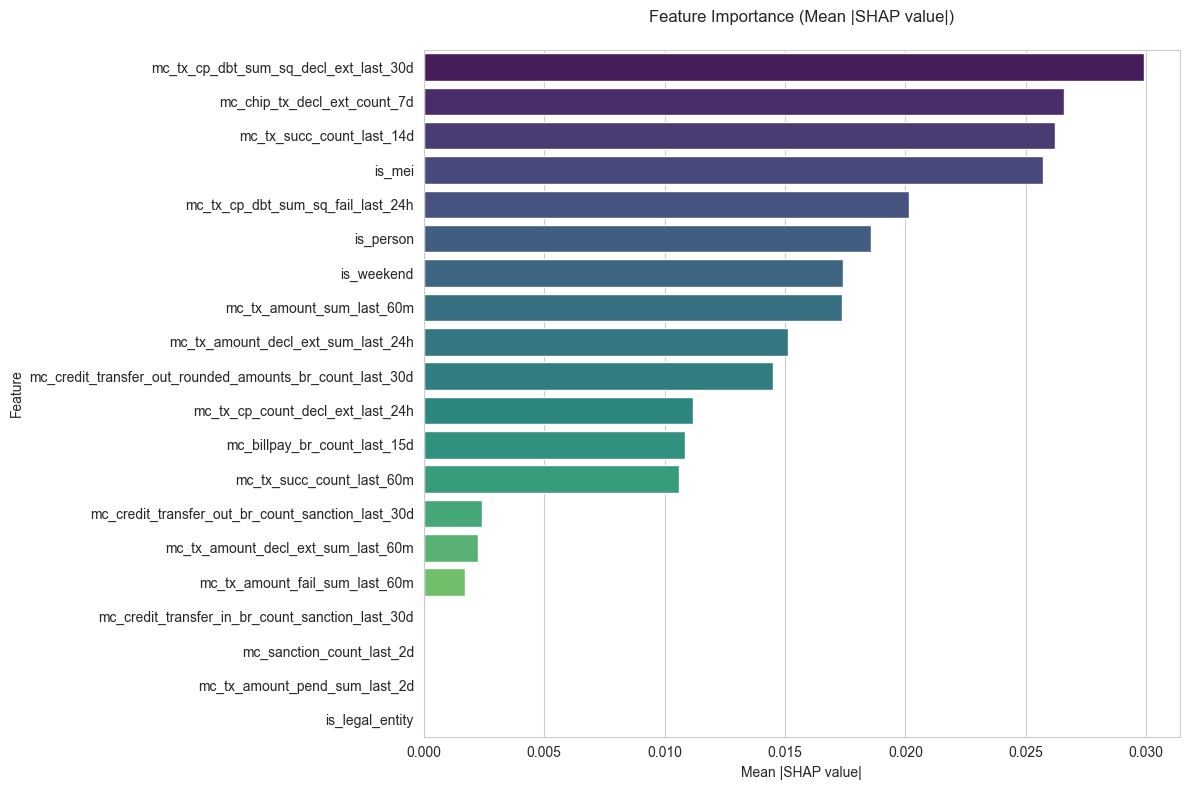

C:\Users\gabri\AppData\Local\Temp\ipykernel_18676\2685198620.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


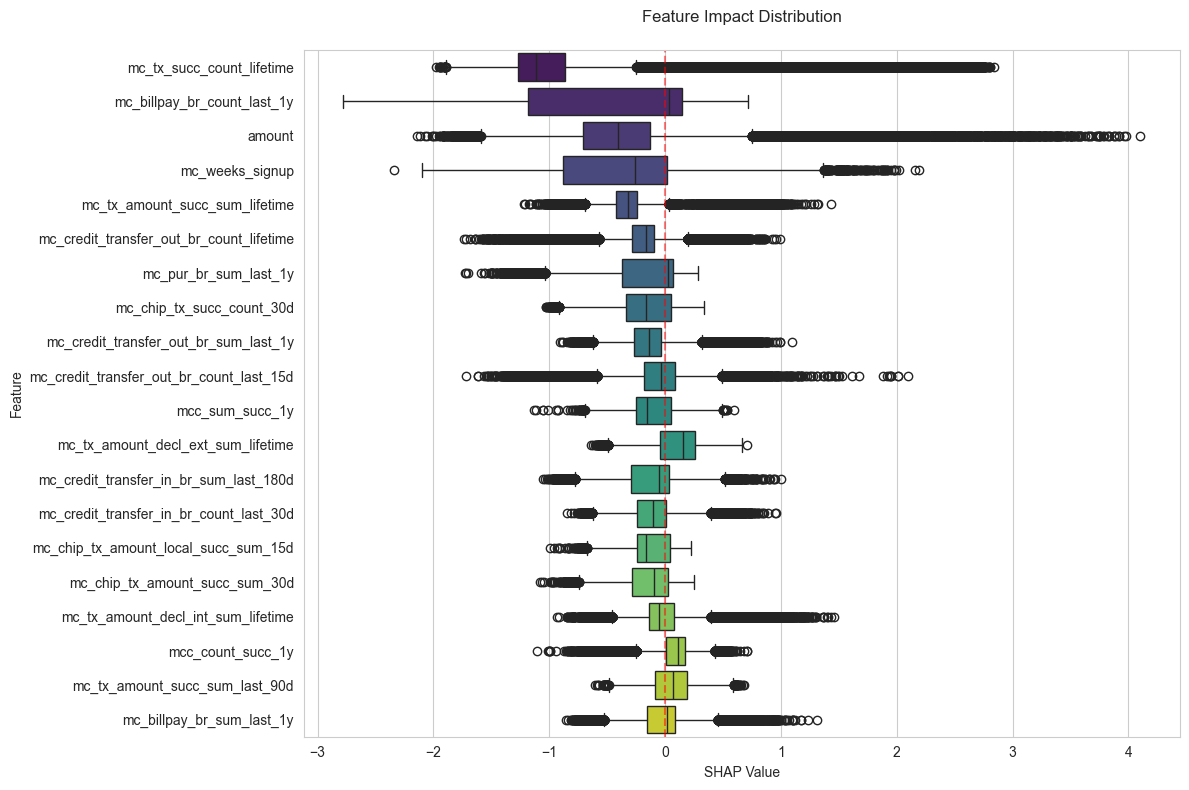

C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\gabri\AppData\Local\Temp\ipykernel_18676\2685198620.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


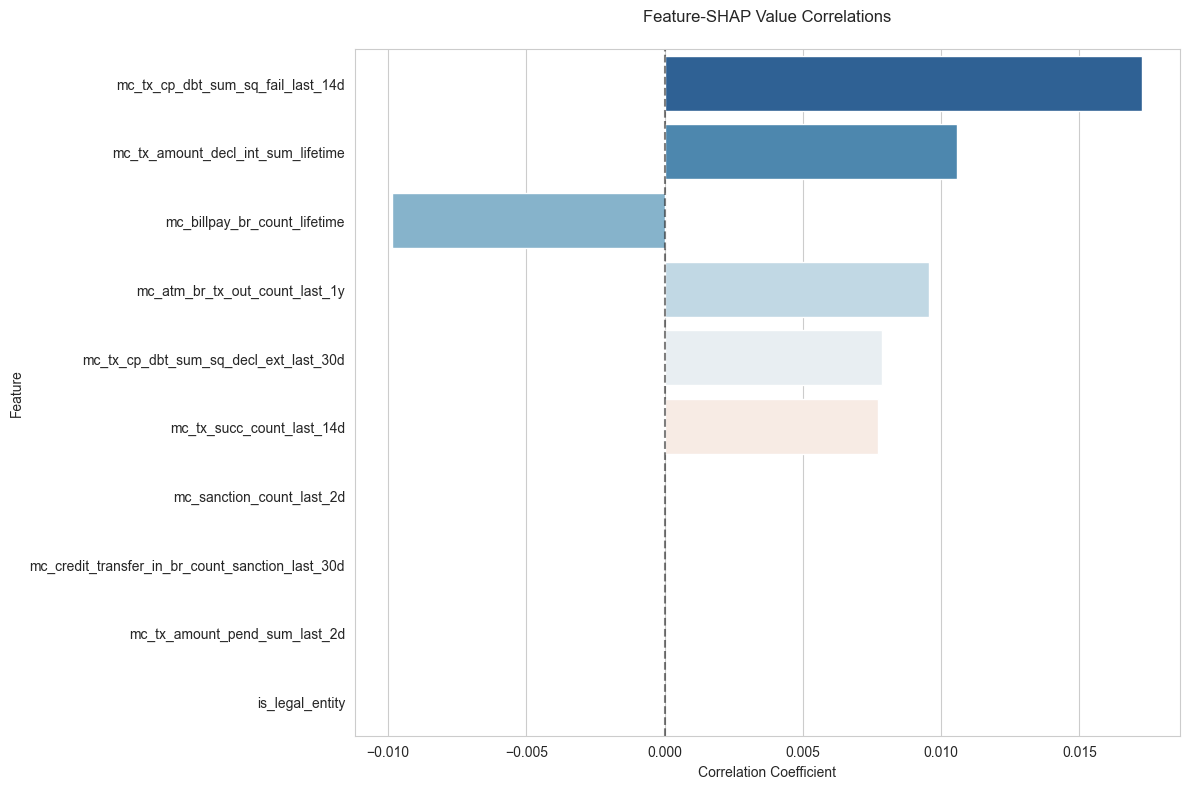

C:\Users\gabri\AppData\Local\Temp\ipykernel_18676\2685198620.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


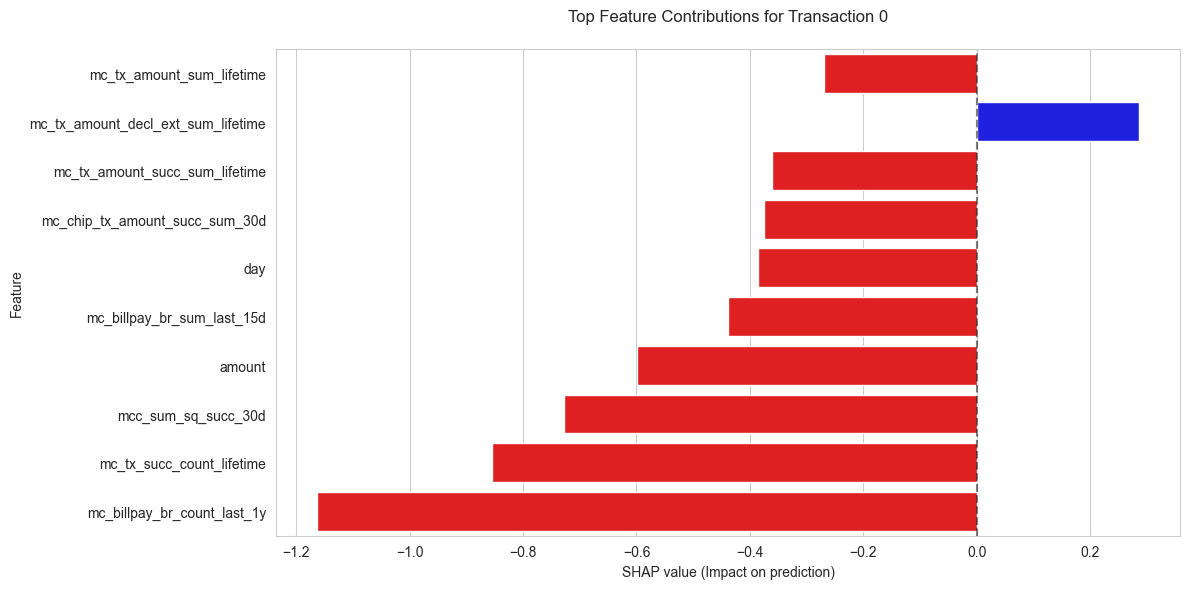


Top Feature Contributions:
                               Feature  SHAP value             Value
5          mc_billpay_br_count_last_1y     -1.1632           19.0000
59           mc_tx_succ_count_lifetime     -0.8545           46.0000
81                 mcc_sum_sq_succ_30d     -0.7280 690773887363.2681
0                               amount     -0.5984          107.5000
4           mc_billpay_br_sum_last_15d     -0.4395           65.5105
91                                 day     -0.3852            1.0000
39      mc_chip_tx_amount_succ_sum_30d     -0.3749          932.3138
53      mc_tx_amount_succ_sum_lifetime     -0.3617        12398.4369
44  mc_tx_amount_decl_ext_sum_lifetime      0.2857         5446.4928
57           mc_tx_amount_sum_lifetime     -0.2688        18401.6468


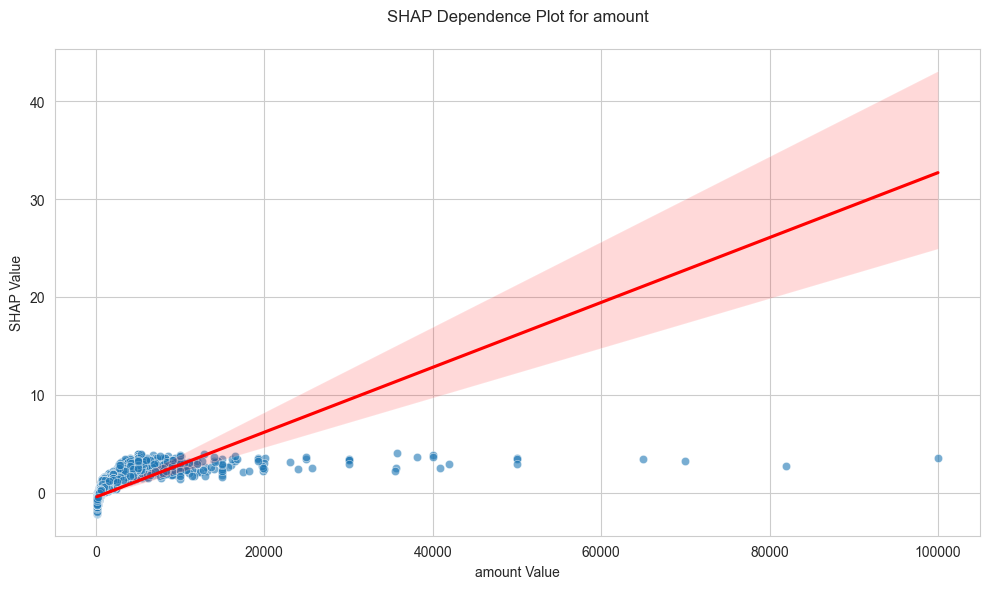

In [8]:
# Initialize and setup
explainer = ModelExplainer(
    model_path='../model/supervised/xgboost_model_20250212_144931.pkl',
    data_path='../data/processed/df_treated.csv'
)

# Setup with desired sample size
explainer.setup_explainer(sample_size=1000000)

# Generate all visualizations
# explainer.plot_feature_importance()
# explainer.plot_feature_impact_distribution()
explainer.plot_feature_correlations()
explainer.explain_single_prediction(transaction_idx=0)
explainer.plot_feature_dependence('amount')  # Replace with your feature name